In [1]:
from hcipy import *
from tqdm.notebook import tqdm
from OpticalSystem import ShimmOptic
from atm import InfiniteVonKarman, LocalMultiLayerAtmosphere

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
from IPython.display import HTML
import matplotlib.pyplot as plt
from matplotlib import animation

%matplotlib widget

           Caracteristicas de telescopio            
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Parametro                   ┃ Valores            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ Tamaño de la pupila         │ 249                │
│ Tamaño del sensor           │ 256                │
│ Tamaño fisico de la pupila  │ 0.5                │
│ Tamaño del haz en el sensor │ 3.735294117647059  │
└─────────────────────────────┴────────────────────┘

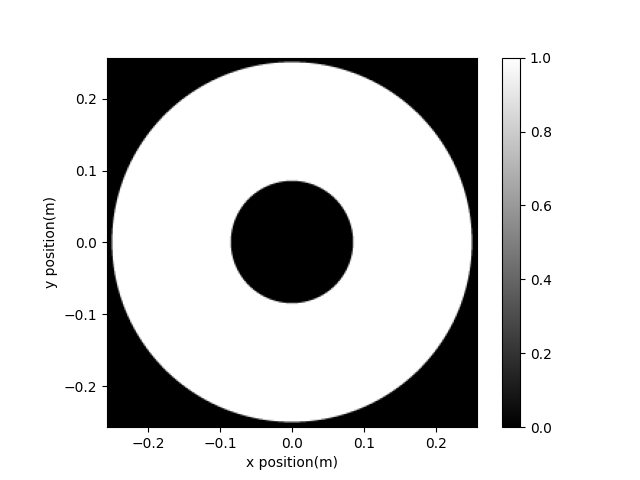

In [2]:
telescope_diameter = 0.5   # diametro telescopio en metros (tipo VLT)
central_obscuration_ratio = 0.34     # obstrucción central
#central_obscuration_ratio = 0     # obstrucción central
pixel_size = 15e-6
telescope_fnumber = 6.8
fach = 25.4e-3
sensorSize = 256

Shimm = ShimmOptic(telescope_diameter,central_obscuration_ratio,fach,pixel_size,sensorSize,SHcentered=False,telescope_fnumber=telescope_fnumber)
Shimm.pupil_info(True)


# Diam = 480*telescope_diameter/200

(256, 256)


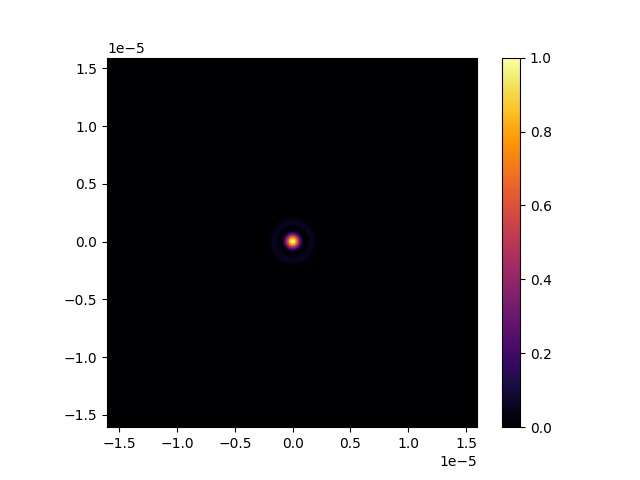

In [3]:
wavelength = 500e-9

pos_star_1 = np.array([np.radians(0/2/3600),0.0])
wf = Wavefront(Shimm.aperture, wavelength)
wf.total_power = 1

# wf.total_power = 10000 
spatial_resolution = (wavelength / telescope_diameter)
focal_grid = make_focal_grid(q=8, num_airy=16, spatial_resolution=spatial_resolution)

propagator = FraunhoferPropagator(Shimm.sensor_grid, focal_grid)

unaberrated_PSF = propagator.forward(wf).power
print(unaberrated_PSF.shaped.shape)
# 
plt.figure()
imshow_field(unaberrated_PSF / unaberrated_PSF.max(), cmap='inferno')
plt.colorbar()

0.0005


              Shack hartman caracteristicas              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Parametro                         ┃ Valores           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Cantidad de subaperturas visibles │ 7                 │
│ f_number Shack Hartmann           │ 65.60000000000001 │
│ Tamaño fisico                     │ 0.01              │
│ centrado                          │ False             │
└───────────────────────────────────┴───────────────────┘

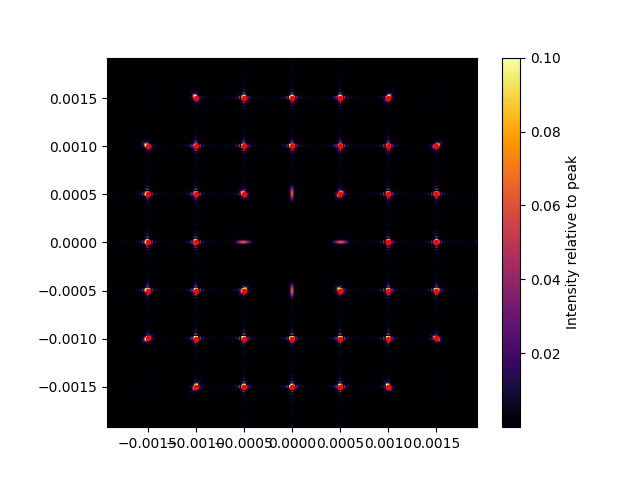

In [4]:

num_lenslets = 20
lenslet_diameter = 0.5e-3
focal_length = 32.8e-3

shwfs = Shimm.ShackHartman(lenslet_diameter,num_lenslets,focal_length,wavelength)
magnifier = Shimm.magnifier 
image_ref = shwfs(Shimm.magnifier(wf)).power
shwfse = Shimm.estimator(shwfs,image_ref)

slope_ref = shwfse.estimate([image_ref])

plt.figure()
imshow_psf(image_ref,scale="linear",normalization="peak"  )
plt.plot(slope_ref[0,:],slope_ref[1,:],".",color="r")

In [5]:

glob_cn = Cn_squared_from_fried_parameter(0.15)

p1 = fried_parameter_from_Cn_squared(glob_cn * 0.2)
p2 = fried_parameter_from_Cn_squared(glob_cn * 0.8)
pg = ((p1)**(-5/3) + (p2)**(-5/3)) ** (-3/5)
print(pg)

0.14999999999999997


In [ ]:
# camera = NoisyDetector(focal_grid,include_photon_noise=True,dark_current_rate=0)

aperture_grid = make_pupil_grid(Shimm.sensorSize,Shimm.D_t * Shimm.oversizing_factor)

T = 0.1e-3
print(1/2e-3)
glob_cn = Cn_squared_from_fried_parameter(0.15)

layer2 = InfiniteVonKarman(input_grid=aperture_grid,
                          height=10e3,
                          Cn_squared=glob_cn*0.8,
                          direction=100,
                          seed=1,
                          fps=int(1/T),
                          L0=25,
                          l0=0.01,
                          speed=8,
                          D_tel=telescope_diameter,
                          N = Shimm.sensorSize)

layer1 = InfiniteVonKarman(input_grid=aperture_grid,
                          height=0e3,
                          Cn_squared=glob_cn*0.2,
                          direction=30,
                          seed=1,
                          fps=int(1/T),
                          L0=25,
                          l0=0.01,
                          speed=8,
                          D_tel=telescope_diameter,
                          N = Shimm.sensorSize)



atm = LocalMultiLayerAtmosphere([layer1,layer2],scintillation=True)

camera = NoiselessDetector(Shimm.sensor_grid)

camera.integrate((shwfs(magnifier(wf))),2e-3)  # captura con tiempo de expocision de 2 ms
wfs_image = camera.read_out()

Vmin = 0
Vmax = wfs_image.max()

frames = []
labels = []
steps = 1500
for i in tqdm(range(steps)):
    for _ in range(20):
        atm.evolve()
        camera.integrate((shwfs(magnifier(atm(wf)))),0.1e-3)  # captura con tiempo de expocision de 2 ms

    wfs_image = camera.read_out()


    # Apply pupil mask if needed
    frames.append(wfs_image.shaped)
    labels.append(f"Frame {i+1}")
    atm.evolve()

fig, ax = plt.subplots(figsize=(5,5), dpi=100)
ax.set_axis_off()
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
# first frame
im = ax.imshow(frames[0], animated= True,vmin=0,vmax=Vmax,cmap="gray")
txt = ax.text(5, 10, labels[0], color='white', fontsize=10)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Intensidad", rotation=270, labelpad=15)



fps_ani = 10  # 10 frames per second

def update(k):
    im.set_array(frames[k])
    txt.set_text(labels[k])
    return im, txt

movie = animation.FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=1000/fps_ani,   # ms between frames
    blit=True
)
plt.close(fig)
HTML(movie.to_jshtml())



500.0
czz
czx
cxx
czz
czx
cxx


  0%|          | 0/1500 [00:00<?, ?it/s]

500.0
czz
czx
cxx


/tmp/ipykernel_25838/2304184358.py:56: DeprecationWarning: Please import `sum_labels` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  fluxes = ndimage.measurements.sum_labels(image, mla_index, shwfse.estimation_subapertures)# type: ignore
/tmp/ipykernel_25838/2304184358.py:57: DeprecationWarning: Please import `sum_labels` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  sum_x = ndimage.measurements.sum_labels(image * image_ref.grid.x, mla_index, shwfse.estimation_subapertures)# type: ignore
/tmp/ipykernel_25838/2304184358.py:58: DeprecationWarning: Please import `sum_labels` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  sum_y = ndimage.measurements.sum_labels(image * image_ref.grid.y, mla_index, shwfse.estimation_subapertures)# type: ignor

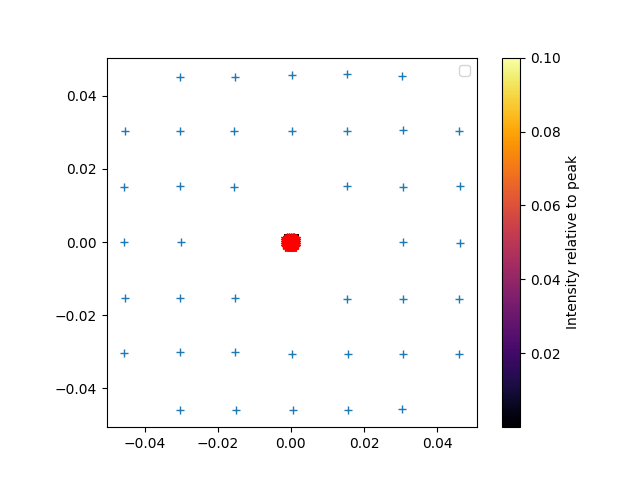

In [ ]:

aperture_grid = make_pupil_grid(Shimm.sensorSize,Shimm.D_t * Shimm.oversizing_factor)

T = 0.1e-3
print(1/2e-3)
glob_cn = Cn_squared_from_fried_parameter(0.08)

# layer2 = InfiniteVonKarman(input_grid=aperture_grid,
                        #   height=10e3,
                        #   Cn_squared=glob_cn,
                        #   direction=100,
                        #   seed=1,
                        #   fps=int(1/T),
                        #   L0=25,
                        #   l0=0.01,
                        #   speed=8,
                        #   D_tel=telescope_diameter,
                        #   N = Shimm.sensorSize)

layer1 = InfiniteVonKarman(input_grid=aperture_grid,
                          height=0e3,
                          Cn_squared=glob_cn,
                          direction=30,
                          seed=1,
                          fps=int(1/T),
                          L0=25,
                          l0=0.01,
                          speed=8,
                          D_tel=telescope_diameter,
                          N = Shimm.sensorSize)



atm = LocalMultiLayerAtmosphere([layer1],scintillation=True)

camera = NoiselessDetector(Shimm.sensor_grid)

camera.integrate((shwfs(magnifier(wf))),2e-3)  # captura con tiempo de expocision de 2 ms
image_ref = camera.read_out()

  
# Slopes de una imagen aberrada  
camera.integrate(shwfs(magnifier(atm(wf))), 1)  
image = camera.read_out()  

slopes = shwfse.estimate([image])
  
